# Stage 1: Data Understanding

This notebook validates the runtime data acquisition layer for Phase 1. It downloads data directly from Yahoo Finance, inspects adjusted close prices and volume, checks missing values, and visualizes the sample asset universe.

## Objectives

- Use the `YahooFinanceProvider` directly at runtime.
- Download the sample universe: `HDFCBANK.NS`, `TCS.NS`, `GOLDBEES.NS`.
- Validate dates, adjusted close coverage, volume coverage, and missing values.
- Produce in-memory outputs: `prices_df` and `volume_df`.
- Visualize price behavior and data completeness before moving to returns.

In [21]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_pipeline import SAMPLE_UNIVERSE, YahooFinanceProvider, build_data_inspection_table

In [22]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2020-01-01"
end_date = "2024-12-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

prices_df = market_data.prices_df
volume_df = market_data.volume_df
inspection_df = build_data_inspection_table(market_data)

print(f"Price field used: {market_data.price_field}")
print(f"Price shape: {prices_df.shape}")
print(f"Volume shape: {volume_df.shape}")

2026-06-04 05:48:54,900 - yfinance - ERROR - history.py:139 - $TATAMOTORS.NS: possibly delisted; no timezone found
2026-06-04 05:48:55,044 - yfinance - ERROR - multi.py:187 - 
1 Failed download:
2026-06-04 05:48:55,045 - yfinance - ERROR - multi.py:195 - ['TATAMOTORS.NS']: possibly delisted; no timezone found
Price field used: Adj Close
Price shape: (1237, 30)
Volume shape: (1237, 30)


In [23]:
prices_df.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,RELIANCE.NS,SBIN.NS,SILVERBEES.NS,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1705.415161,745.586853,433.316437,453.636475,554.488342,34.349998,450.694275,605.529358,1749.931396,519.137878,...,675.324219,303.138489,NaN,406.074036,306.714355,NaN,1841.149292,602.617493,3942.765625,113.709183
2020-01-02,1702.990112,753.802612,435.132721,451.348816,551.696045,34.349998,451.954987,609.389099,1751.286987,522.861511,...,686.821289,307.534393,NaN,406.681793,306.240845,NaN,1832.697876,605.740906,4117.158691,113.984627
2020-01-03,1665.661621,739.860779,435.037109,447.964905,555.354919,35.400002,461.016876,600.698853,1741.708252,521.169006,...,687.648804,302.458710,NaN,415.704529,301.363312,NaN,1869.221924,612.896973,4092.328125,115.269997
2020-01-06,1623.578003,720.242676,429.827393,444.914551,554.382446,36.150002,458.613708,587.698730,1730.864868,508.450531,...,671.700684,289.134949,NaN,411.356781,295.586060,NaN,1869.052490,609.180603,4032.095947,115.751999
2020-01-07,1639.983765,722.732239,425.477936,446.678040,555.412720,35.500000,460.386475,597.004822,1735.609009,505.742432,...,682.034546,288.591095,NaN,417.387665,298.237946,NaN,1873.639282,614.478516,4114.539551,117.152138


In [24]:
volume_df.head()

Ticker,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,RELIANCE.NS,SBIN.NS,SILVERBEES.NS,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,397285,4917748,5154996,1316812,773895,847673,918373,3673698,543035,7642793,...,14004468,17379320,NaN,2321850,1514293,NaN,1354908,746371,163949,2827732
2020-01-02,411266,5156046,4933053,1406381,1494155,710354,1075642,6137166,663275,10264223,...,17710316,20324236,NaN,4555670,3091351,NaN,2380752,1133488,1458328,2887932
2020-01-03,1318628,8489729,5154587,2252752,1723390,2322978,3269446,10855550,1598825,9594690,...,20984698,21853208,NaN,9457180,1718884,NaN,4655761,2121704,635983,6762808
2020-01-06,1871804,6356198,7538915,1501855,1788685,8276750,3589985,10890186,683129,12534334,...,24519177,35645325,NaN,4794923,1712158,NaN,3023209,1734439,462841,9133390
2020-01-07,1033650,9103360,4353883,2365554,1788175,2634222,3179728,14724494,808935,16101835,...,16683622,50966826,NaN,4504083,2146089,NaN,2429317,1937143,524372,8805574


In [25]:
inspection_df

,price_field,start_date,end_date,price_observations,volume_observations,missing_prices,missing_volume,dates_monotonic_increasing
symbol,,,,,,,,
ASIANPAINT.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
AXISBANK.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
BHARTIARTL.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
CIPLA.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
DRREDDY.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
GOLDBEES.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
HCLTECH.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
HDFCBANK.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True
HINDUNILVR.NS,Adj Close,2020-01-01,2024-12-30,1237,1237,0,0,True


In [26]:
prices_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ASIANPAINT.NS,1237.0,2700.852810,522.926674,1430.820068,2439.877197,2874.570801,3077.290283,3460.255127
AXISBANK.NS,1237.0,818.073016,230.109949,301.889496,682.691406,778.648865,989.540039,1316.175171
BHARTIARTL.NS,1237.0,802.886564,334.679899,381.532776,535.169250,712.788513,901.990784,1756.416504
CIPLA.NS,1237.0,994.360827,297.935514,360.910828,816.070740,932.630005,1182.926270,1662.738037
DRREDDY.NS,1237.0,965.420159,187.897820,505.296112,846.074158,927.978149,1102.221069,1403.588257
GOLDBEES.NS,1237.0,47.410210,7.530650,34.349998,41.820000,44.549999,51.450001,67.019997
HCLTECH.NS,1237.0,967.250729,343.315341,320.840088,769.278931,946.070801,1121.446289,1847.663940
HDFCBANK.NS,1237.0,703.751573,106.952174,363.573364,664.348999,720.387512,780.400513,923.393494
HINDUNILVR.NS,1237.0,2263.620277,236.178367,1661.149414,2073.096436,2278.783203,2439.935791,2939.454590


In [27]:
volume_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
ASIANPAINT.NS,1237.0,1.498777e+06,1.102682e+06,112249.0,805874.0,1167742.0,1851739.0,11545923.0
AXISBANK.NS,1237.0,1.400134e+07,1.142361e+07,460781.0,7077669.0,9874576.0,16351052.0,96186227.0
BHARTIARTL.NS,1237.0,1.114209e+07,1.342252e+07,279441.0,4566333.0,7149094.0,13115141.0,198547005.0
CIPLA.NS,1237.0,3.420983e+06,3.916609e+06,96347.0,1359682.0,2048750.0,3986238.0,56895213.0
DRREDDY.NS,1237.0,3.606204e+06,5.068278e+06,104180.0,1527165.0,2274150.0,3978630.0,109935390.0
GOLDBEES.NS,1237.0,5.119380e+06,3.780611e+06,0.0,2670040.0,3986932.0,6162885.0,37546218.0
HCLTECH.NS,1237.0,4.283615e+06,3.320620e+06,242223.0,2306173.0,3357203.0,5196000.0,32312474.0
HDFCBANK.NS,1237.0,2.671162e+07,2.477248e+07,1096808.0,13249642.0,21187024.0,33877466.0,445342100.0
HINDUNILVR.NS,1237.0,2.138539e+06,5.451746e+06,118532.0,1207402.0,1631747.0,2277437.0,185669922.0


In [28]:
missing_summary = pd.concat(
    [prices_df.isna().sum().rename("missing_prices"), volume_df.isna().sum().rename("missing_volume")],
    axis=1,
)
missing_summary

,missing_prices,missing_volume
Ticker,,
ASIANPAINT.NS,0,0
AXISBANK.NS,0,0
BHARTIARTL.NS,0,0
CIPLA.NS,0,0
DRREDDY.NS,0,0
GOLDBEES.NS,0,0
HCLTECH.NS,0,0
HDFCBANK.NS,0,0
HINDUNILVR.NS,0,0


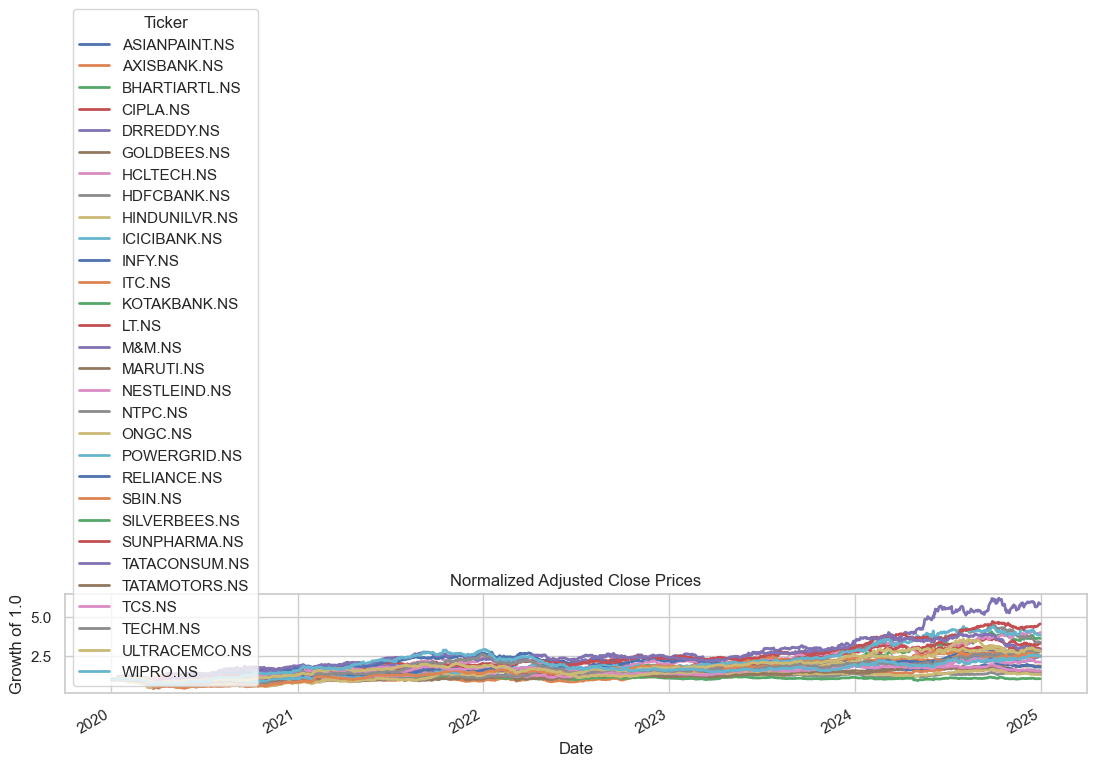

In [29]:
sns.set_theme(style="whitegrid")
normalized_prices = prices_df / prices_df.iloc[0]
ax = normalized_prices.plot(figsize=(11, 5), linewidth=2)
ax.set_title("Normalized Adjusted Close Prices")
ax.set_ylabel("Growth of 1.0")
ax.set_xlabel("Date")
plt.tight_layout()

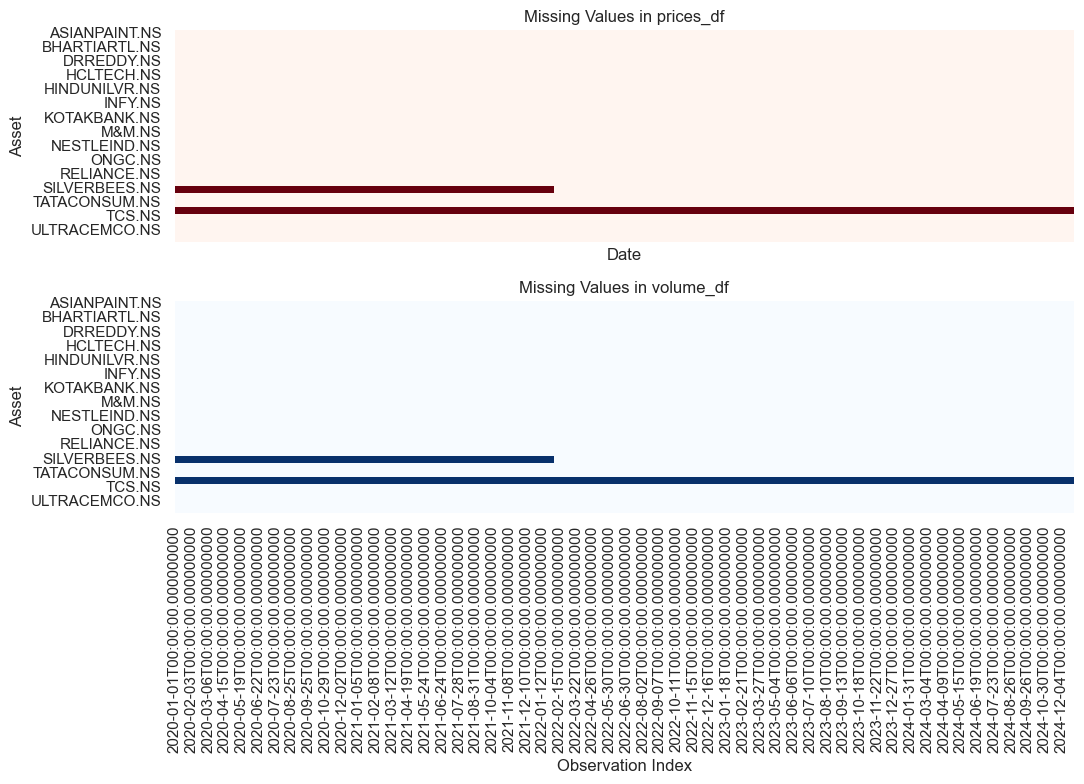

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
prices_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Reds", cbar=False, ax=axes[0])
axes[0].set_title("Missing Values in prices_df")
axes[0].set_ylabel("Asset")

volume_df.isna().astype(int).T.pipe(sns.heatmap, cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Missing Values in volume_df")
axes[1].set_ylabel("Asset")
axes[1].set_xlabel("Observation Index")
plt.tight_layout()

## Interpretation

- `prices_df` is the adjusted close panel used for downstream return calculations.
- `volume_df` helps validate tradability and data completeness before portfolio construction.
- Any missing-value clusters should be handled before returns are computed in Stage 2.
- This stage deliberately keeps all processing in memory and avoids persistent dataset storage.